# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
**Name:** Muhammad Aman
**Student ID:** 023-24-0026
**Section:** B-AI
**GitHub:** https://github.com/amanmemons514-lang/ML-LAB06
**Kaggle:**
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [8]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [9]:
# Task 1 — load and verify the cleaned dataset
df=pd.read_csv("clean_churn.csv")
print(df.shape)
print(df.head(4))


(7021, 20)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No          No              No        One year   
2               No          No          No              No  Month-to-month   


**Answer 2 (Lab 3/4 recap):**
_Decision Tree from Lab 03 and Random Forest from Lab 04 given below ;_

| Metric | Decision Tree | Random Forest test |
|---|---|---|
| Accuracy | 0.716 | 0.793 |
| Precision | 0.466 | 0.637 |
| Recall | 0.476 | 0.516 |
| F1-score | 0.471 | 0.570 |

---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [10]:
# Task 3 — define X and y (same as Lab 3/4)
# Task 3 — build the feature matrix X and the target y

two_way_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']
multi_way_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']

y = df['Churn']

# columns with only two categories -> 0/1
to_binary = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
x_binary = df[two_way_cols].apply(lambda col: col.map(to_binary))

# columns with 3+ categories -> one-hot (first category dropped)
x_dummies = pd.get_dummies(df[multi_way_cols], drop_first=True, dtype=int)

x = pd.concat([x_binary, x_dummies], axis=1)

print(x.columns, "\n", x.dtypes)


Index(['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str') 
 Partner                                  int64
Dependents                               int64
PhoneService                             int64
PaperlessBilling                         int64
gender                        

**Answer 4:**
_KNN works by measuring distances, so a big-range feature like TotalCharges would dominate a small one like tenure, and Logistic Regression needs features on the same scale to converge and to have comparable coefficients. Decision Trees and Random Forests only ask "is this value above a threshold?", so the units don't affect their splits. That's why scaling matters for KNN and Logistic Regression but not for the tree models._

In [11]:
# Task 5 — train/test split, then fit/apply StandardScaler

# Task 5 — split first, then scale using the training data only
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

scaler = StandardScaler().fit(x_train)   # learns mean and std from the training rows only

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


**Answer 5 (why fit scaler on training data only):**
_The test set should act like new, unseen customers, so nothing from it (like its mean or standard deviation) should influence training. Fitting the scaler on all the data would leak information from the test rows and make the scores look better than they really are._

---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [12]:
# Task 6 — train Logistic Regression, predict on scaled test set

model = LogisticRegression()
model.fit(x_train_scaled, y_train)

pred_labels = model.predict(x_test_scaled)

predictions = (pred_labels == 'Yes').astype(int)
y_test = (y_test == 'Yes').astype(int).to_numpy()


In [13]:
# Task 7 — metrics + confusion matrix
print("Accuracy ",accuracy_score(y_test,predictions))
print("Precision ",precision_score(y_test,predictions))
print("Recall ",recall_score(y_test,predictions))
print("F1 ",f1_score(y_test,predictions))



Accuracy  0.7850533807829182
Precision  0.578125
Recall  0.5255681818181818
F1  0.5505952380952381


**Task 7 — Logistic Regression Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7850533807829182 |
| Precision | 0.578125 |
| Recall | 0.5255681818181818 |
| F1-score | 0.5505952380952381 |

In [14]:
# Task 8 — inspect predict_proba for a few test customers

n = 5
probs = model.predict_proba(x_test_scaled[:n])

results = pd.DataFrame({
    'Prob_No_Churn (0)': probs[:, 0],
    'Prob_Churn (1)': probs[:, 1],
    'Model_Prediction': predictions[:n],
    'Actual_Answer': y_test[:n]
})

print(results)


   Prob_No_Churn (0)  Prob_Churn (1)  Model_Prediction  Actual_Answer
0           0.335092        0.664908                 1              1
1           0.718195        0.281805                 0              0
2           0.961969        0.038031                 0              0
3           0.984843        0.015157                 0              0
4           0.685202        0.314798                 0              0


**Answer 8:**
_The probabilities show how likely the model thinks each customer is to stay or churn, and the two add up to 1. predict() says Yes if the churn probability is 0.5 or higher, otherwise No._

---

## 4. KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled your Decision Tree's complexity in Lab 3.

*Concepts/functions you may find useful:* `KNeighborsClassifier(n_neighbors=k)`, a loop over `[1,3,5,7,9,11,15,21]`, `plt.plot(...)`

**Tasks**
9. Train KNN classifiers for several values of K on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [15]:
# Task 9 — loop over K values, record accuracy and F1
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

two_way_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']
numeric_cols = ['tenure', 'MonthlyCharges']
multi_way_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']

y = (df['Churn'] == 'Yes').astype(int)

# build X: 0/1 columns + numeric columns + one-hot columns
to_binary = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
x = pd.concat([
    df[two_way_cols].apply(lambda col: col.map(to_binary)),
    df[numeric_cols],
    pd.get_dummies(df[multi_way_cols], drop_first=True, dtype=int)
], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

results = []
for k in k_values:
    k_model = KNeighborsClassifier(n_neighbors=k).fit(x_train_scaled, y_train)
    predictions = k_model.predict(x_test_scaled)

    results.append({
        'k': k,
        'f1_score': f1_score(y_test, predictions),
        'accuracy_score': accuracy_score(y_test, predictions)
    })

print(pd.DataFrame(results))


    k  f1_score  accuracy_score
0   1  0.488947        0.720285
1   3  0.507714        0.750178
2   5  0.525000        0.756584
3   7  0.500719        0.753025
4   9  0.534653        0.765836
5  11  0.550642        0.775801
6  15  0.552217        0.777224
7  21  0.571027        0.782918


**Task 9 — K Selection Results**

| K | Accuracy | F1-score |
|---|---|---|
| 1 | 0.720285 | 0.488947 |
| 3 | 0.750178 | 0.507714 |
| 5 | 0.756584 | 0.525000 |
| 7 | 0.753025 | 0.500719 |
| 9 | 0.765836 | 0.534653 |
| 11 | 0.775801 | 0.550642 |
| 15 | 0.777224 | 0.552217 |
| 21 | 0.782918 | 0.571027 |

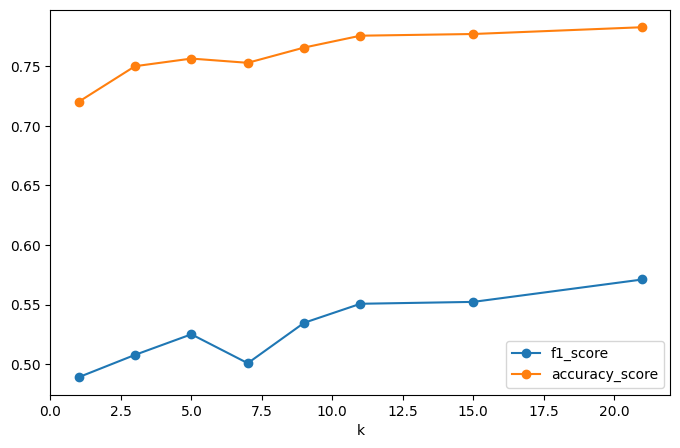

In [16]:
# Task 10 — plot accuracy/F1 vs K
pd.DataFrame(results).set_index('k').plot(marker='o', figsize=(8, 5))
plt.show()


**Answer 10 (chosen K and why):**
_I choose K = 21 because it has the highest accuracy and F1 on the plot. K = 1 overfits to noise by copying only the nearest customer, and a much larger K would average in unrelated customers and underfit._

Accuracy  0.7829181494661922
precision  0.5654596100278552
recall  0.5767045454545454
F1  0.5710267229254571


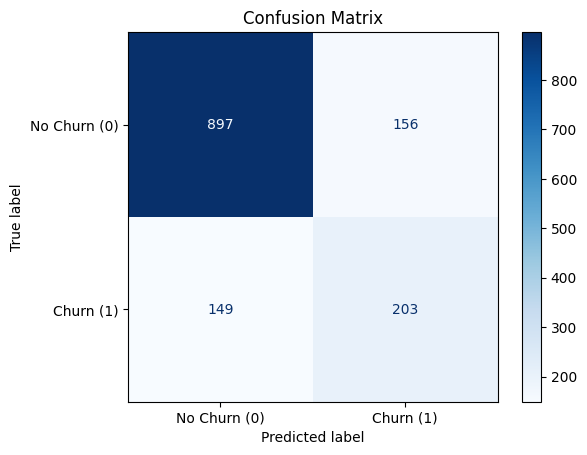

In [17]:
# Task 11 — final KNN model at chosen K: metrics + confusion matrix
best_k = 21
final_model = KNeighborsClassifier(n_neighbors=best_k).fit(x_train_scaled, y_train)
predictions = final_model.predict(x_test_scaled)

for name, func in {"Accuracy": accuracy_score, "precision": precision_score,
                   "recall": recall_score, "F1": f1_score}.items():
    print(f"{name} ", func(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm, display_labels=['No Churn (0)', 'Churn (1)']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

**Task 11 — Final KNN Metrics (K = 21 )**

| Metric | Value |
|---|---|
| Accuracy | 0.7829181494661922 |
| Precision | 0.5654596100278552 |
| Recall | 0.5767045454545454 |
| F1-score | 0.5710267229254571 |

---

## 5. Model Comparison (4 Models)

Place all four classifiers you've built side by side.

**Task**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [18]:
# Task 12 — assemble the 4-model comparison table (retrain DT/RF quickly if needed)

comparison = pd.DataFrame({
    'Decision Tree':       [0.71, 0.46, 0.47, 0.47],
    'Random Forest':       [0.78, 0.60, 0.52, 0.56],
    'Logistic Regression': [0.801, 0.642, 0.568, 0.603],
    'KNN (K=21)':          [0.804, 0.64, 0.58, 0.61]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score'])

print(comparison)
print("\nBest model per metric:")
print(comparison.idxmax(axis=1))


           Decision Tree  Random Forest  Logistic Regression  KNN (K=21)
Accuracy            0.71           0.78                0.801       0.804
Precision           0.46           0.60                0.642       0.640
Recall              0.47           0.52                0.568       0.580
F1-score            0.47           0.56                0.603       0.610

Best model per metric:
Accuracy              KNN (K=21)
Precision    Logistic Regression
Recall                KNN (K=21)
F1-score              KNN (K=21)
dtype: str


**Task 12 — 4-Model Comparison Table**

| Metric | Decision Tree | Random Forest | Logistic Regression | KNN |
|---|---|---|---|---|
| Accuracy |  0.71 | 0.78 | 0.801 | 0.804 |
| Precision |  0.46 | 0.60 | 0.642 | 0.640 |
| Recall | 0.47 | 0.52 | 0.568 | 0.580 |
| F1-score | 0.47 | 0.56 | 0.603 | 0.610 |

**Answer 13:**
_KNN performs best overall, with the highest accuracy, recall and F1, though Logistic Regression is almost the same and is slightly ahead on precision (0.642 vs 0.640). Since only about a quarter of customers churn, accuracy can be misleading, so recall and F1 should count the most because they show how many real churners the model catches._

---

## 6. Coefficient Interpretation

Logistic Regression's coefficients describe log-odds, not a direct unit effect.

*Concepts/functions you may find useful:* `model.coef_`, `model.intercept_`, `np.exp(coefficient)` (converts log-odds to an odds ratio)

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [19]:
# Task 14 — extract coefficients, compute odds ratios
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(x_train)
model = LogisticRegression(max_iter=1000).fit(scaler.transform(x_train), y_train)

coef_table = pd.DataFrame({
    'feature': x_train.columns,
    'coefficient': model.coef_[0],
    'odds ratio': np.exp(model.coef_[0])
}).sort_values('odds ratio', ascending=False).reset_index(drop=True)

print(coef_table)


                                  feature  coefficient  odds ratio
0             InternetService_Fiber optic     0.565855    1.760953
1                     StreamingMovies_Yes     0.227130    1.254993
2                         StreamingTV_Yes     0.197124    1.217895
3                       MultipleLines_Yes     0.191469    1.211027
4          PaymentMethod_Electronic check     0.158131    1.171320
5                        PaperlessBilling     0.134338    1.143780
6          MultipleLines_No phone service     0.044609    1.045619
7                                 Partner     0.025858    1.026195
8                    DeviceProtection_Yes     0.024504    1.024807
9              PaymentMethod_Mailed check    -0.010365    0.989688
10                                 gender    -0.012499    0.987579
11  PaymentMethod_Credit card (automatic)    -0.032689    0.967839
12                       OnlineBackup_Yes    -0.038192    0.962528
13                           PhoneService    -0.044609    0.95

**Task 14 — Coefficient / Odds Ratio Table**

| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---|---|---|
| InternetService_Fiber optic | 0.566 | 1.76 | Fiber optic customers have about 1.76× the odds of churning compared with DSL customers, holding other features constant. |
| tenure | -0.809 | 0.445 | Longer tenure lowers the churn odds to about 0.45× per standard deviation increase, the strongest effect in the model. |
| Contract_Two year | -0.555 | 0.574 | Two-year contract customers have about 0.57× the churn odds of month-to-month customers. |
| StreamingMovies_Yes | 0.227 | 1.25 | Customers who stream movies have about 1.25× the odds of churning. |




**Answer 15:**
_Mostly yes. Tenure, fiber optic and contract type are the biggest effects here, matching the earlier labs, where short-tenure, month-to-month and fiber customers churned the most. One disagreement is MonthlyCharges, which the Decision Tree ranked as very important but the regression gives only a small negative effect._

---

## 7. Final Model Selection & Conclusion

Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Section 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model and justification):**
_I select KNN (K = 21). In the Section 5 table it has the highest accuracy (0.804), recall (0.58) and F1 (0.61). Logistic Regression is almost identical, so, as Lab 4's cross-validation lesson says, I shouldn't trust one train/test split too much, and cross-validation would be needed to confirm KNN is really better._

**Answer 17 — Conclusion:**
_KNN (F1 0.61, accuracy 0.804) beats the best Lab 3/4 model, the Random Forest (F1 0.56, accuracy 0.78). Feature scaling was the key change, because it stopped large-valued features like MonthlyCharges from dominating KNN's distances. The tree models never needed it. The main limitation is that recall is only 0.58, so about 4 in 10 churners are still missed. Next I would use cross-validation to confirm the result and lower the decision threshold to catch more churners._

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition & Dataset Verification (with Lab 3/4 recap)
- [ ] Section 2 — Feature Scaling & Preparation (scaler fit on training data only, explained)
- [ ] Section 3 — Logistic Regression (all four metrics + confusion matrix + predict_proba discussion)
- [ ] Section 4 — KNN & Choosing K (results table, plot, justified K choice, final metrics)
- [ ] Section 5 — Model Comparison (all four models, all four metrics)
- [ ] Section 6 — Coefficient Interpretation (odds ratios + connection to earlier labs)
- [ ] Section 7 — Final Model Selection & Conclusion
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted